**AI disclosure:** no generative AI was used at any point for the contents of this file.<br>
This Jupyter Notebook was produced by Luna Sarrazin (thomas.sarrazin@mail.utoronto.ca), 
with suggestions and review by Ömer Can Caner (omer.caner@mail.utoronto.ca).

In [97]:
import numpy as np
import PIL
from PIL import Image
import matplotlib.pyplot as plt

Reading image data

In [98]:
def img_to_mean(filename, folder):
    """
    Return a the mean ADU value of the file with the specified filename in the specified folder.
    """
    img = Image.open(f'{folder}/{filename}')
    arr = np.array(img) # read as 480 lines of 752 pixels
    return np.mean(arr)

means = []

# read data from light frames
for speed in [1, 5, 10, 15, 20, 25, 30]:
    frames = []

    with open(f'{speed}ms/images.txt') as f:

        # create array of image filenames without newline character
        filenames = f.read().splitlines() 
        for i in range(0, 5): # values for each shutter speed
            frames.append(img_to_mean(filenames[i], f'{speed}ms'))
        
        means.append(frames)

# contains mean per trial per shutter speed, ordered by increasing shutter speed (1, 5, 10, 15, 20, 25, 30ms)
mean_array = np.array(means)

# check for outliers
print(mean_array)

[[ 9.47443484  9.46993573  9.4792193   9.45629156  9.46250831]
 [ 9.5778535   9.58356051  9.59864251  9.59235095  9.58666057]
 [ 9.80860483  9.79115969  9.77661237  0.04190215  9.79064993]
 [ 9.93842808  9.93104222  9.93161292  0.04250055  0.04208223]
 [10.08729222 10.07282524 10.08862478  0.04308234  0.04339539]
 [10.2197695  10.20940547 10.24479167  0.04572806  0.04379987]
 [10.37738531 10.40196144 10.39943761 10.38158522 10.38364916]]


Now, we can start doing some data manipulation! We'll calculate a mean per shutter speed and an uncertainty. We'll also exclude the outliers from the data above (values close to 0). This was an oversight when thinking about the number of samples to take; it would have been best to get more samples. 

In [112]:
def selective_mean(arr, min_value):
    """
    Return the mean of arr only taking into account values superior or equal to min_value, 
    and the array containing these values.
    """
    selected = []
    
    for elem in arr:
        if elem >= min_value:
            selected.append(elem)
    
    np_selected = np.array(selected)
    
    return (np.mean(np_selected), np_selected)
            

aggregate_means_inter = [] # intermediate array
aggregate_uncerts_inter = [] # idem

for i in range(0, 7):
    mean, array = selective_mean(mean_array[i], 5)
    
    aggregate_means_inter.append(mean)
    aggregate_uncerts_inter.append(np.std(array) / (np.float64(len(array))**0.5)) #TODO: make dependent on std? https://www.reddit.com/r/Physics/comments/7b078p/uncertainty_calculations_for_the_average_of_a/

aggregate_means = np.array(aggregate_means_inter)
aggregate_uncerts = np.array(aggregate_uncerts_inter)

shutters = np.array([0.001, 0.005, 0.010, 0.015, 0.020, 0.025, 0.030])

print(aggregate_means)
print(aggregate_uncerts)
print(shutters)

[ 9.46847795  9.58781361  9.7917567   9.93369441 10.08291408 10.22465555
 10.38880375]
[0.00367223 0.00320297 0.00567226 0.00193719 0.00413071 0.00857582
 0.00445089]
[0.001 0.005 0.01  0.015 0.02  0.025 0.03 ]


We can plot these points and the error bars, although we expect the bars to not be noticeable given their very small scale.

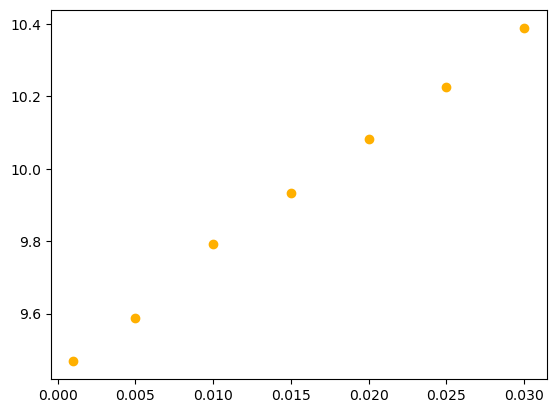

In [115]:
# plot the photon-transfer curve 
fig, ax = plt.subplots(1)
ax.errorbar(shutters, aggregate_means, yerr=aggregate_uncerts, color="#FFB000", fmt="None")
ax.scatter(shutters, aggregate_means, color="#FFB000")

Finally, let's plot a least squares regression of the data:

Slope: 31.55981310706309; Intercept: 9.447539407579534


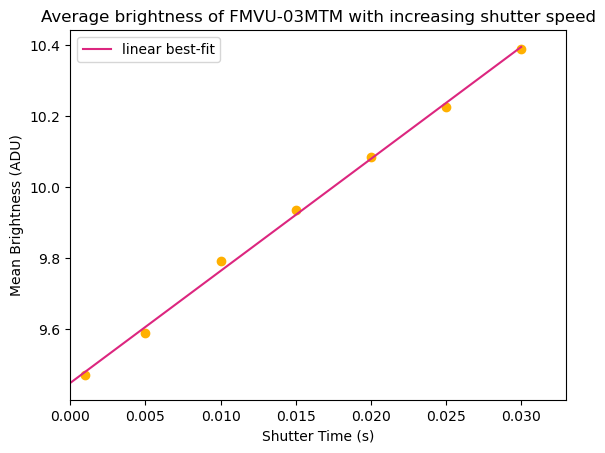

In [127]:
def least_squares(x_arr, y_arr, N):
    """
    Return a tuple of gradient (m) and constant (c) for linear regression using values from arrays x_arr and y_arr.
    Both arrays contain N entries.
    """    
    x_arr2 = x_arr ** 2
    xy_arr = x_arr * y_arr
    
    sum_x = np.sum(x_arr)
    sum_y = np.sum(y_arr)
    sum_x2 = np.sum(x_arr2)
    sum_xy = np.sum(xy_arr)
    
    det = (N * sum_x2 - sum_x ** 2)**(-1)

    m = det * (sum_xy * N - sum_y * sum_x)
    c = det * (sum_y * sum_x2 - sum_xy * sum_x)

    return (m, c)

fig, ax = plt.subplots(1)
ax.errorbar(shutters, aggregate_means, yerr=aggregate_uncerts, color="#FFB000", fmt="None")
ax.scatter(shutters, aggregate_means, color="#FFB000")

m, c = least_squares(shutters, aggregate_means, np.size(shutters))

xrange = np.arange(0, 0.031, 0.001)
ax.plot(xrange, xrange * m + c, color="#DC267F", label="linear best-fit")

ax.set_xlim(0, 0.033)
ax.set_xlabel("Shutter Time (s)")
ax.set_ylabel("Mean Brightness (ADU)")
ax.set_title("Average brightness of FMVU-03MTM with increasing shutter speed")
ax.legend(loc="upper left")

print(f'Slope: {m}; Intercept: {c}')

The slope gives the cumulative dark current from all pixels, in ADU/sec. We need to divide this by the number of pixels of the camera to obtain the actual dark current. This gives us the following:

In [124]:
dark_current = c / 360960 # yes this is a magic number, but it's the 0.3Mpx from the CMOS camera.
print("Dark Current of FMVU-03MTM:", dark_current, "ADU/s/px")

Dark Current of FMVU-03MTM: 2.617336936940252e-05 ADU/s/px
